# Bose-Einstein condensation

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

In this notebook we will simulate an ideal Bose gas to observe Bose-Einstein Condensation (BEC). This is a cornerstone of quantum statistical mechanics and directly relates to topics like superfluidity mentioned in the course.

Unlike classical particles, identical quantum particles are indistinguishable. For bosons (particles with integer spin), any number of them can occupy the same quantum state.

- **Bose-Einstein Statistics**: At a given temperature, the particles distribute themselves among the available energy levels ($\epsilon_0,\epsilon_1,\epsilon_2,\dots$).
- **Bose-Einstein Condensation**: Below a certain critical temperature ($T_c$), a macroscopic fraction of the entire system's particles suddenly drops into the lowest energy state (the ground state, $\epsilon_0$). This condensed portion of the gas has zero viscosity (it's a superfluid) and other exotic quantum properties.

Instead of tracking individual particles, our simulation will track the occupation number ($n_i$) for each energy level $\epsilon_i$. We will use a Monte Carlo algorithm to find the most probable distribution $(n_0,n_1,n_2,\dots)$ at a given temperature.

This script simulates non-interacting bosons in a simplified set of energy levels (e.g., those of a harmonic oscillator). It will:
1. Initialize $N$ particles in $M$ energy levels.
2. Use the Metropolis algorithm to move particles between levels until thermal equilibrium is reached.
3. Plot the final distribution of particles over the energy levels.

The code will clearly show the formation of a condensate at low temperatures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [16]:
N = 5000        # Total number of particles (bosons)
M = 100         # Number of energy levels
n_steps = 50_000_000  # Number of Monte Carlo steps

# Energy levels of a harmonic oscillator: E_i = i
energies = np.arange(M, dtype=np.float64)

In [27]:
@njit
def run_bec_simulation(N, M, energies, T, n_steps):
    """Monte Carlo simulation of ideal Bose gas occupation numbers."""
    # Start with all particles in the ground state
    occupation = np.zeros(M, dtype=np.int64)
    occupation[0] = N

    for step in range(n_steps):
        # Pick two different energy levels
        i = np.random.randint(0, M)
        j = np.random.randint(0, M)
        if i == j:
            continue

        # Can only move a particle from level i if it's occupied
        if occupation[i] > 0:
            dE = energies[j] - energies[i]
            ni = occupation[i]
            nj = occupation[j]
            # Bose-Einstein acceptance ratio:
            # includes the statistical weight factor ni/(nj+1)
            acceptance_ratio = np.exp(-dE / T) #* (ni / (nj + 1.0))

            if np.random.random() < acceptance_ratio:
                occupation[i] -= 1
                occupation[j] += 1

    return occupation

In [28]:
# Warm up numba JIT
_ = run_bec_simulation(10, 5, np.arange(5, dtype=np.float64), 1.0, 100)

In [41]:
T = 400.0  # Temperature (in units of energy/k_B)
print(f"Simulating Ideal Bose Gas for T = {T}...")
final_distribution = run_bec_simulation(N, M, energies, T, n_steps)
print("Simulation finished.")

Simulating Ideal Bose Gas for T = 400.0...
Simulation finished.


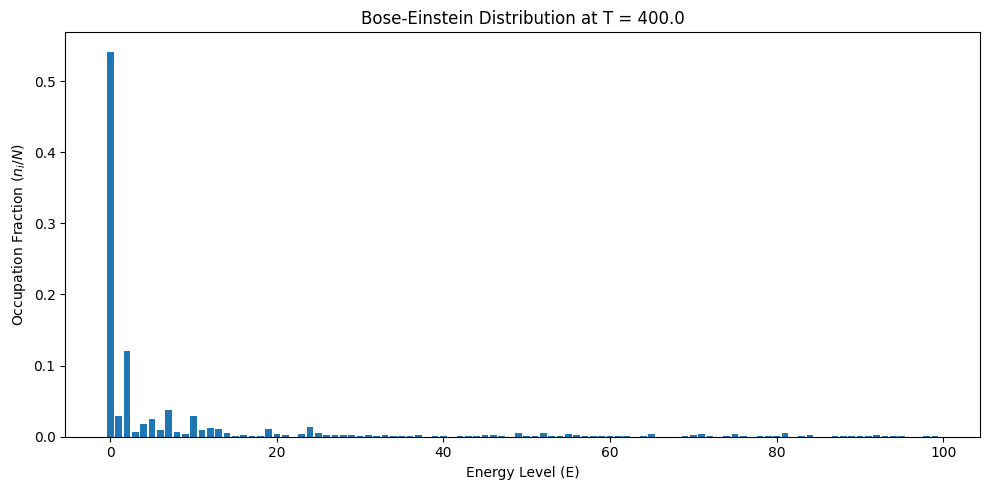

Fraction of particles in the ground state (E=0): 54.14%


In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(energies, final_distribution / N, width=0.8)
ax.set_xlabel("Energy Level (E)")
ax.set_ylabel("Occupation Fraction ($n_i / N$)")
ax.set_title(f"Bose-Einstein Distribution at T = {T}")
plt.tight_layout()
plt.show()

ground_state_fraction = final_distribution[0] / N
print(f"Fraction of particles in the ground state (E=0): {ground_state_fraction * 100:.2f}%")